In [13]:
#from google.colab import drive
#drive.mount('/content/drive')

In [14]:
import sys
#sys.path.append(r"C:\Users\Michael Ocampo\Documents\P_Files\opensees\final_\functions")
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")

In [15]:
#!sudo apt update
#!sudo apt install libglu1-mesa libglu1-mesa-dev
#!pip install -r requirements.txt

In [16]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import time as tt
import gmsh
import solver_function as SF
import materialParam as param
import RCs_section as RCS
import importlib
importlib.reload(SF)
importlib.reload(param)
importlib.reload(RCS)
from solver_function import *
from materialParam import *
from RCs_section import *

In [17]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (154528435268)>


In [18]:
# Define constants
E = 2.1e11       # Elastic modulus of the foundation material (Pa)
H = 0.5          # Height (thickness) of the foundation (m)
B = 5.0          # Width of the foundation (m)
L = 10.0         # Length of the foundation (m)
K = 1e8          # Modulus of subgrade (soil spring stiffness) reaction (Pa/m)
P = -1e6         # Compression force applied at the center of the foundation (N)

# Derived properties
nu = 0.3         # Poisson's ratio for the foundation material
rho = 2500       # Density of the foundation material (kg/m^3)

t = H            # Thickness of the shell elements

# Derived properties
I = B * H**3 / 12  # Moment of inertia for the rectangular cross-section (m^4)

# Discretization
nx = 50  # Number of grid points along length
ny = 25  # Number of grid points along width
dx = L / (nx - 1)
dy = B / (ny - 1)

#############################
#  FINITE DIFFERENCE METHOD #
#############################

# Define finite difference matrices
nodes = nx * ny  # Total number of nodes
A = np.zeros((nodes, nodes))  # Coefficient matrix
b = np.zeros(nodes)          # Right-hand side vector

# Helper functions for indexing in 2D
index = lambda i, j: i * ny + j

# Populate finite difference matrix
for i in range(1, nx - 1):
    for j in range(1, ny - 1):
        idx = index(i, j)

        # Contributions from bending in x-direction
        A[idx, index(i - 1, j)] += E * I / dx**4
        A[idx, index(i + 1, j)] += E * I / dx**4
        A[idx, idx] -= 2 * E * I / dx**4

        # Contributions from bending in y-direction
        A[idx, index(i, j - 1)] += E * I / dy**4
        A[idx, index(i, j + 1)] += E * I / dy**4
        A[idx, idx] -= 2 * E * I / dy**4

        # Soil spring contribution
        A[idx, idx] += K

# Apply compression force at the center of the foundation
center_x, center_y = nx // 2, ny // 2
b[index(center_x, center_y)] -= P / (dx * dy)  # Convert force to pressure

# Boundary conditions (fixed edges: zero displacement)
for i in range(nx):
    for j in [0, ny - 1]:  # Fixed along y-edges
        A[index(i, j), index(i, j)] = 1
        b[index(i, j)] = 0
for j in range(ny):
    for i in [0, nx - 1]:  # Fixed along x-edges
        A[index(i, j), index(i, j)] = 1
        b[index(i, j)] = 0

# Solve for displacements
y_fd = np.linalg.solve(A, b).reshape((nx, ny))

# Calculate reactions (subgrade reaction)
reactions_fd = -K * y_fd

In [19]:
# OpenSees Modeling
ops.wipe()
ops.model("BasicBuilder", "-ndm", 3, "-ndf", 6)

ops.uniaxialMaterial("ENT", 1, K)            # No Tension Soil
#ops.uniaxialMaterial("Elastic", 1, K)       # Soil
# Create nodes
node_tags = {}
spring_tags = {}
tag = 1
spring_tag = 1
NZ = 200000 # soil spring base node started
for i in range(nx):
    for j in range(ny):
        x = i * dx
        y = j * dy
        node_tags[(i, j)] = tag
        ops.node(tag, x, y, 0.0)
        # Create a spring node directly below the foundation node
        spring_node = tag + nodes + NZ
        spring_tags[(i, j)] = spring_node
        ops.node(spring_node + NZ, x, y, 0.0)       # define base soil springs nodes
        ops.fix(spring_node + NZ, 1, 1, 1, 1, 1, 1) # fix base soil springs nodes
        # Create zero-length element for vertical spring
        ops.element("zeroLength", spring_node, spring_node + NZ, tag, "-mat", 1, "-dir", 3)
        spring_tag += 1
        tag += 1

In [20]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=True, show_nodal_loads = False)

In [21]:
# Define material and section
ops.nDMaterial("ElasticIsotropic", 1, E, nu, rho)
ops.section("PlateFiber", 1, 1, t)

# Create ShellMITC4 elements
tag = 1
element_tags = {}
for i in range(nx - 1):
    for j in range(ny - 1):
        node1 = node_tags[(i, j)]
        node2 = node_tags[(i + 1, j)]
        node3 = node_tags[(i + 1, j + 1)]
        node4 = node_tags[(i, j + 1)]
        ops.element("ShellMITC4", tag, node1, node2, node3, node4, 1)
        element_tags[(i, j)] = tag
        tag += 1

# Apply distributed load
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

center_tag = node_tags[(center_x, center_y)]
ops.load(center_tag, 0.0, 0.0, P, 0.0, 0.0, 0.0)

In [22]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=True, show_nodal_loads = False)

In [23]:
# Run analysis
ops.constraints('Transformation')
ops.numberer('RCM')
ops.system("BandGeneral")
ops.integrator("LoadControl", 1.0)
ops.algorithm("Linear")
ops.analysis("Static")
ops.analyze(1)

# Extract results
displacements = np.zeros((nx, ny))
reactions_os = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        disp = ops.nodeDisp(node_tags[(i, j)], 3)  # Z-direction displacement
        displacements[i, j] = disp
        reactions_os[i, j] = -K * disp

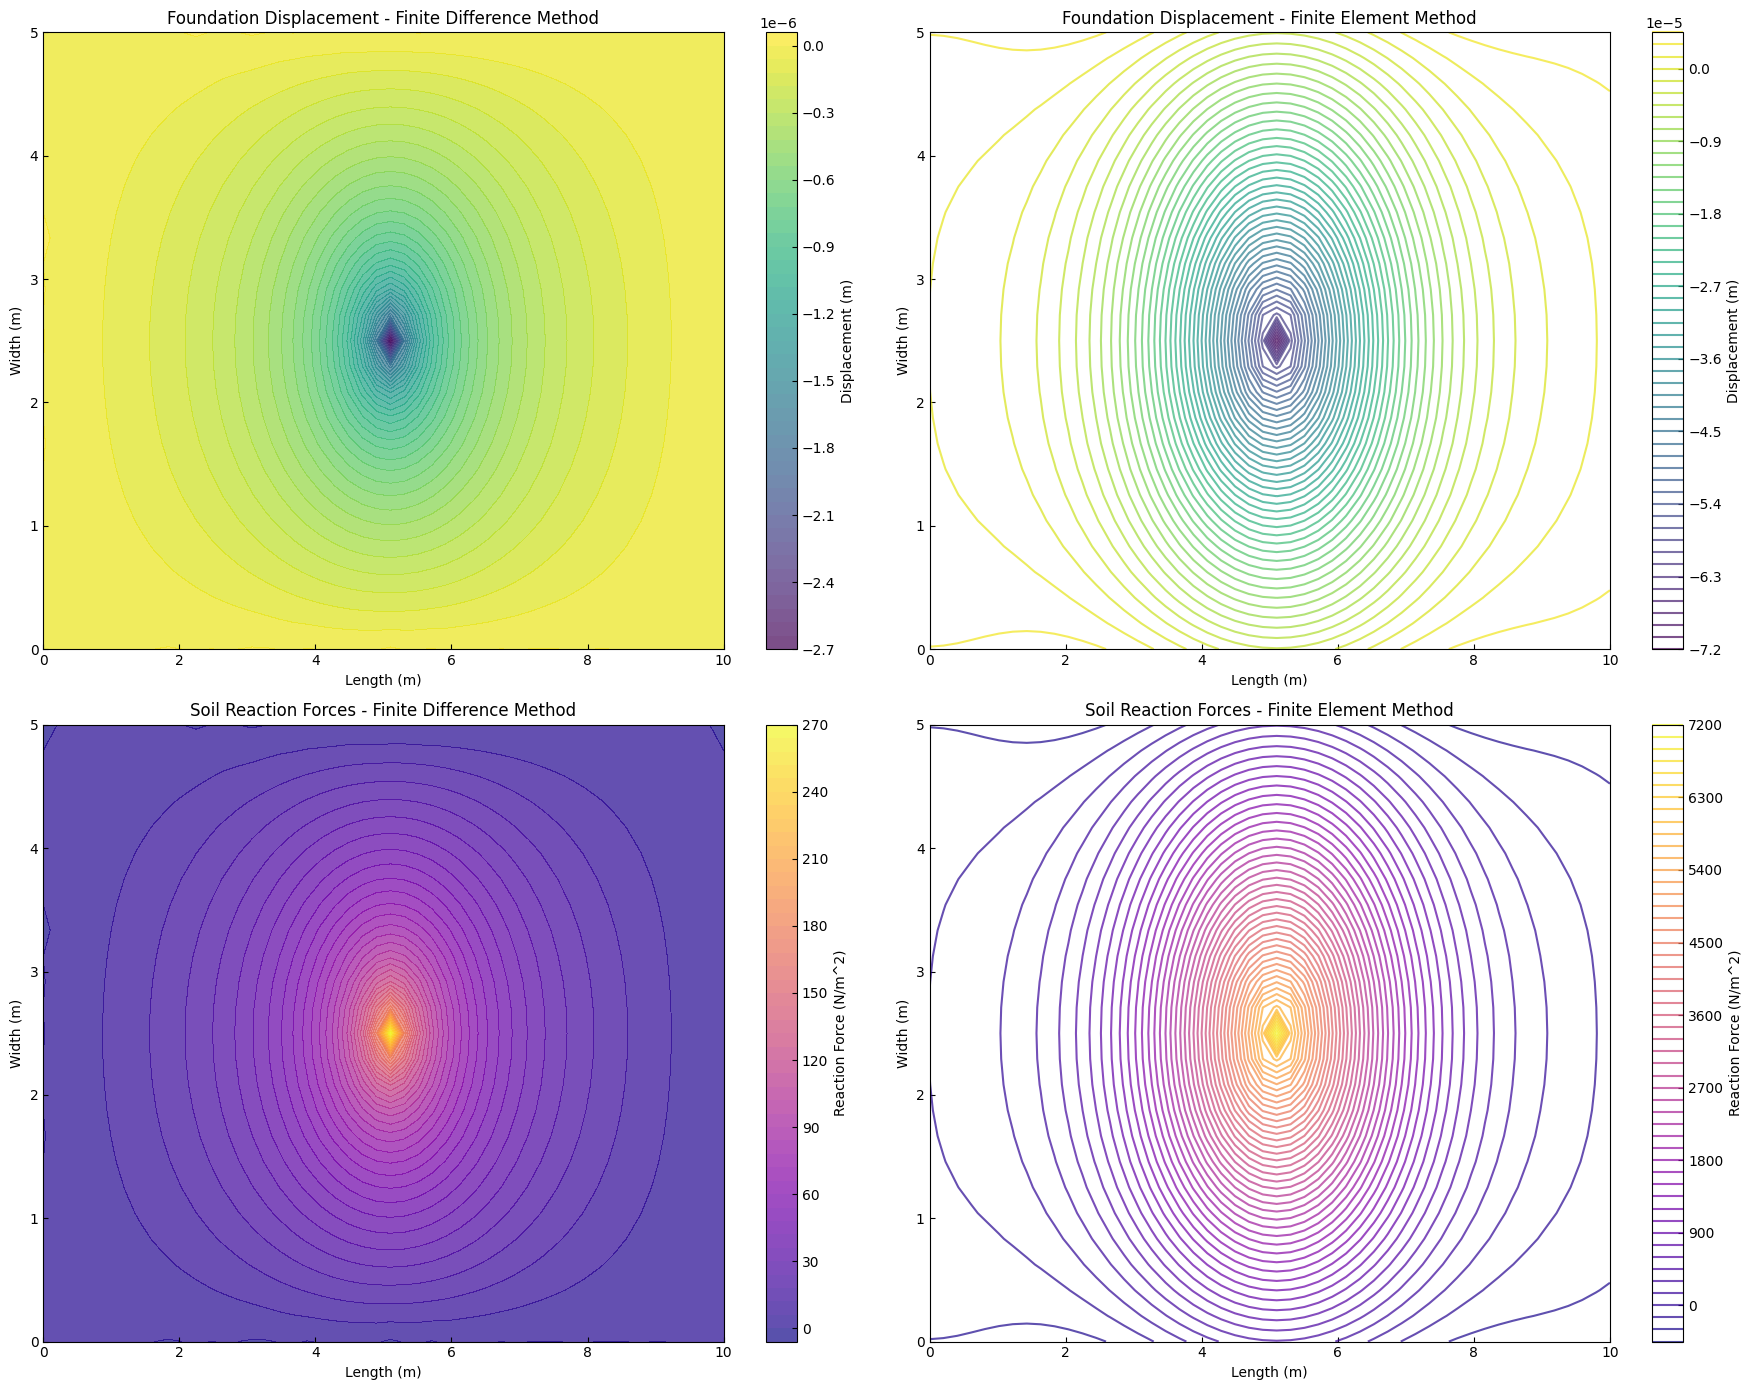

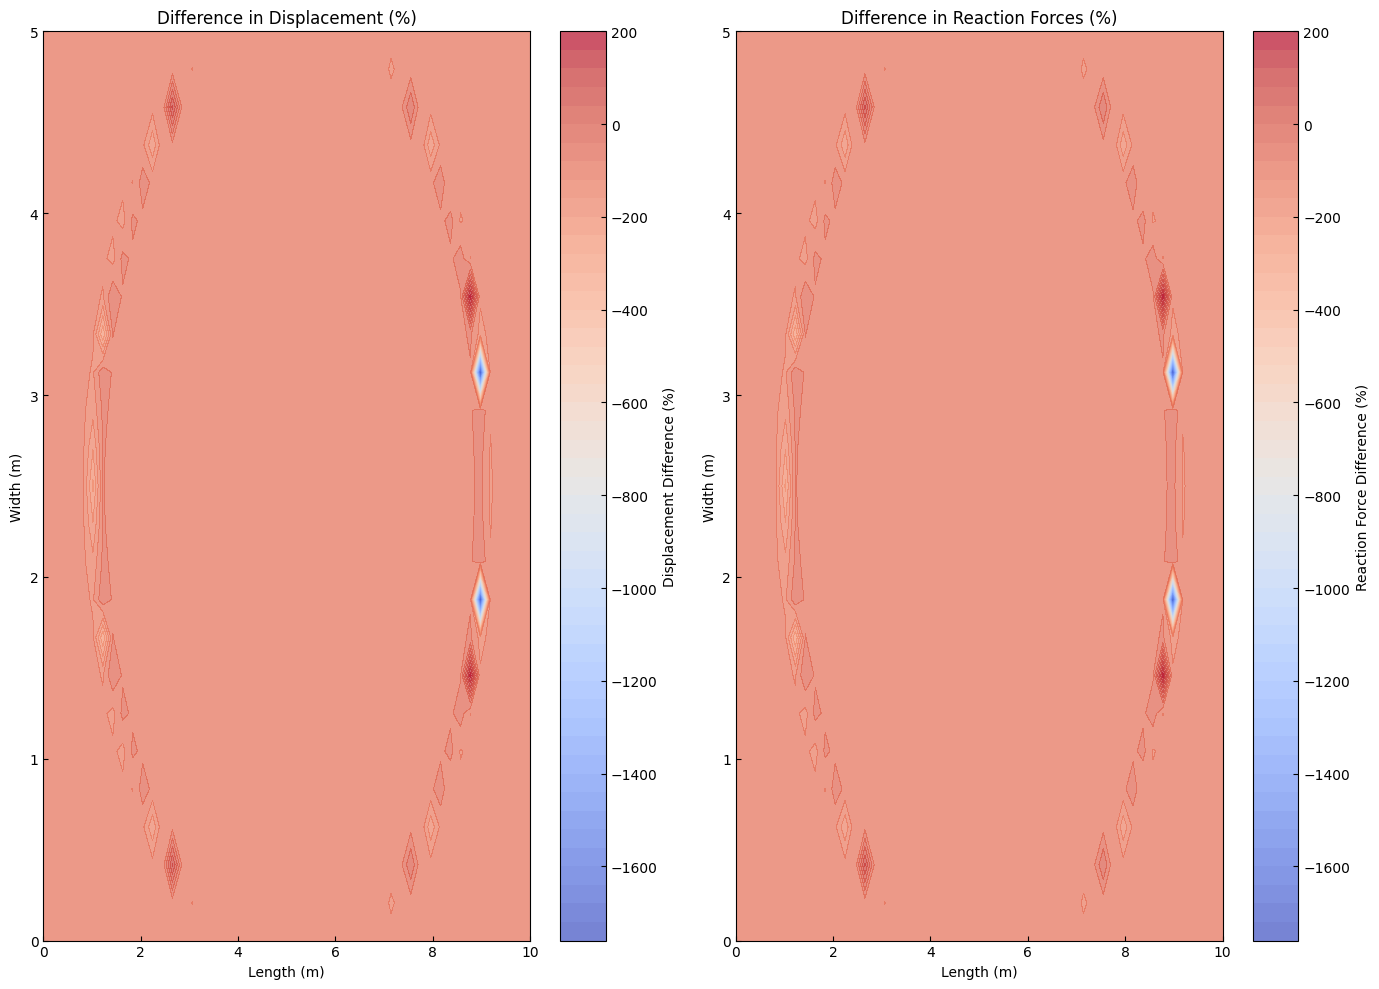

In [24]:
################
# Plot Results #
################

x = np.linspace(0, L, nx)
y_coords = np.linspace(0, B, ny)
X, Y = np.meshgrid(x, y_coords)

plt.figure(figsize=(18, 14))

# Plot displacement
plt.subplot(2, 2, 1)
plt.contourf(X, Y, y_fd.T, levels=50, cmap="viridis", alpha=0.7)
plt.colorbar(label="Displacement (m)")
plt.title("Foundation Displacement - Finite Difference Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.subplot(2, 2, 2)
plt.contour(X, Y, displacements.T, levels=50, cmap="viridis", alpha=0.7)  # , linestyles='--'
plt.colorbar(label="Displacement (m)")
plt.title("Foundation Displacement - Finite Element Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

# Plot soil reactions
plt.subplot(2, 2, 3)
plt.contourf(X, Y, reactions_fd.T, levels=50, cmap="plasma", alpha=0.7)
plt.colorbar(label="Reaction Force (N/m^2)")
plt.title("Soil Reaction Forces - Finite Difference Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.subplot(2, 2, 4)
plt.contour(X, Y, reactions_os.T, levels=50, cmap="plasma", alpha=0.7)  # , linestyles='--'
plt.colorbar(label="Reaction Force (N/m^2)")
plt.title("Soil Reaction Forces - Finite Element Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

plt.tight_layout()
plt.show()

####################
# Plot Differences #
####################

# Calculate percentage differences
displacement_diff = np.where(displacements != 0, ((y_fd / displacements) - 1) * 100, 0)
reaction_diff = np.where(reactions_os != 0, ((reactions_fd / reactions_os) - 1) * 100, 0)

# Plot percentage differences
plt.figure(figsize=(14, 10))

# Displacement percentage difference
plt.subplot(1, 2, 1)
plt.contourf(X, Y, displacement_diff.T, levels=50, cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Displacement Difference (%)")
plt.title("Difference in Displacement (%)")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

# Reaction percentage difference
plt.subplot(1, 2, 2)
plt.contourf(X, Y, reaction_diff.T, levels=50, cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Reaction Force Difference (%)")
plt.title("Difference in Reaction Forces (%)")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

plt.tight_layout()
plt.show()